# Part 1: Exploratory Data Analysis

GBV Tweet Classification Challenge. This notebook is the complete, self-contained record of the exploratory analysis for Part 1. Every output below is followed by a short explanation of what it shows and why it matters, so this notebook can be read on its own when writing the Data Understanding section of the report, without needing to re-derive anything.

It reads the cleaned data produced by `src/data_prep.py`. Run that script first if `data/processed/train_cleaned.csv` does not exist yet.

In [1]:
import os
import sys

# Google Colab only: fetch the repo so the relative paths in this notebook resolve.
if 'google.colab' in sys.modules:
    if not os.path.exists('NLP-and-Language-Technologies'):
        get_ipython().system('git clone -q https://github.com/Ebi-Tech/NLP-and-Language-Technologies.git')
    os.chdir('NLP-and-Language-Technologies/notebooks')

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/train_cleaned.csv')
df['word_len'] = df['tweet_clean'].str.split().str.len()
df['char_len'] = df['tweet_clean'].str.len()
df.shape

(39650, 8)

**What this shows:** the cleaned dataset has 39,650 rows and 8 columns (`Tweet_ID`, `tweet`, `type`, `label`, `label_id`, `tweet_clean`, plus the `word_len` and `char_len` columns computed here). The row count matches the original `Train.csv` exactly, confirming that cleaning in `src/data_prep.py` did not drop or duplicate any rows.

## Class distribution

The task is 5-class classification. The first question is how the examples are spread across those 5 classes.

In [3]:
counts = df['label'].value_counts()
pct = df['label'].value_counts(normalize=True) * 100
pd.DataFrame({'count': counts, 'pct': pct.round(2)})

,count,pct
label,,
sexual_violence,32648,82.34
physical_violence,5946,15.00
emotional_violence,651,1.64
economic_violence,217,0.55
harmful_traditional_practice,188,0.47


**What this shows:** the classes form a severe long tail rather than a simple majority/minority split. `sexual_violence` alone accounts for 82.34% of the data, `physical_violence` for 15.00%, and the remaining three classes (`emotional_violence`, `economic_violence`, `harmful_traditional_practice`) together make up only about 2.66%, with the two smallest at 217 and 188 rows respectively. This is the single most important fact about this dataset: it rules out accuracy as a meaningful standalone metric, since a model could reach roughly 82% accuracy by predicting `sexual_violence` for everything and never getting a single other class right. It also makes the validation/test split strategy (the fixed stratified split built in `src/data_prep.py`) a real design decision, since a naive split risks leaving almost no examples of the smallest classes in validation or test.

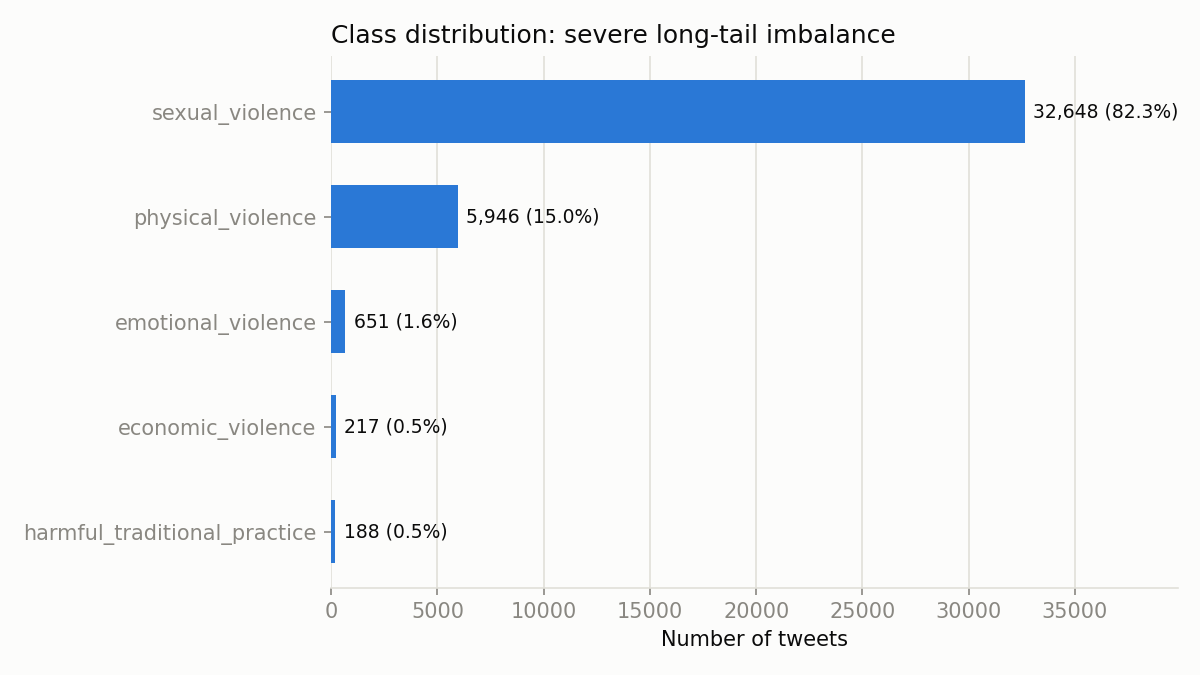

In [4]:
from IPython.display import Image
Image('../reports/figures/class_distribution.png')

**What this shows:** the same numbers as a chart, and the visual gap is stark: the `sexual_violence` bar dwarfs the other four combined, and the three rarest classes are barely visible as bars at all. This is the chart to reference directly in the report when arguing that macro-F1 and per-class recall are necessary alongside (or instead of) accuracy.

## Tweet length

Next question: how long are these tweets, and is this dataset closer to short social-media text or longer-form writing?

In [5]:
df[['word_len', 'char_len']].describe().round(2)

,word_len,char_len
count,39650.00,39650.00
mean,38.89,198.57
std,15.15,76.73
min,2.00,10.00
25%,26.00,133.00
50%,43.00,224.00
75%,52.00,269.00
max,68.00,306.00


**What this shows:** the median length is 43 words (224 characters), with a minimum of 2 words and a maximum of 68 words (306 characters). Even the 25th percentile is 26 words. This is materially longer than typical short-form tweets, which changes which prior literature is actually relevant (short-document classification is a better fit than short-text/tweet classification) and informs the max sequence length choice for the neural models.

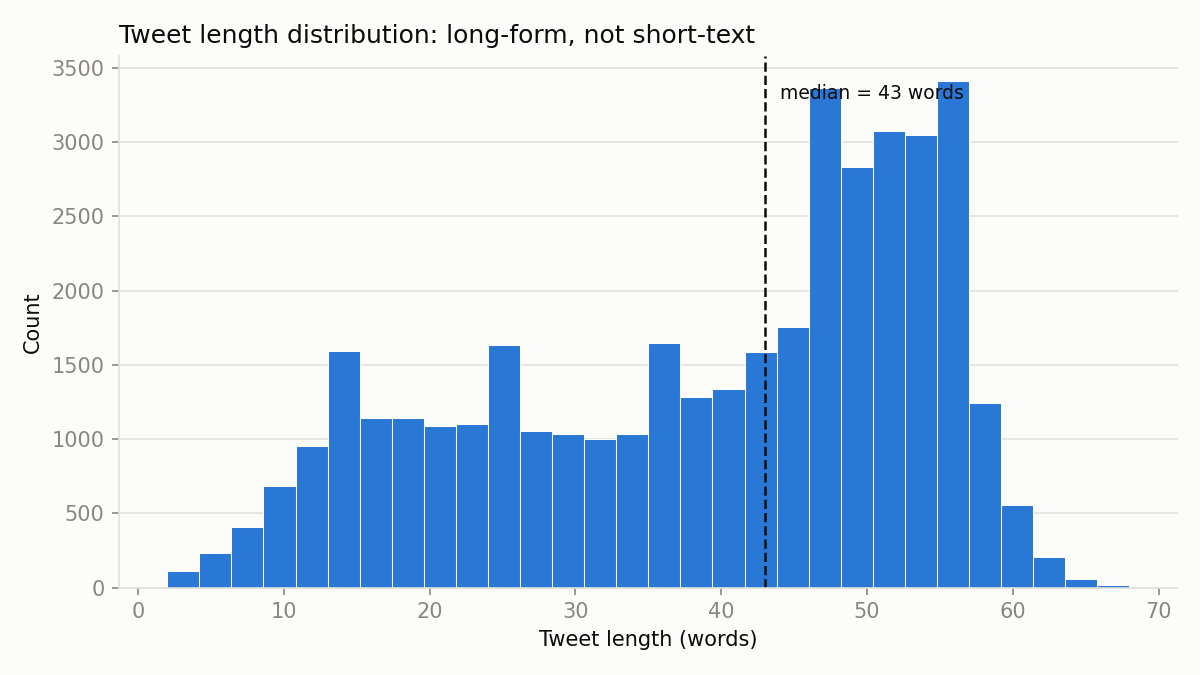

In [6]:
Image('../reports/figures/length_histogram.png')

**What this shows:** the distribution is not a smooth natural curve. It climbs unevenly and then clusters heavily in the 45-58 word range before dropping sharply at a hard ceiling of 68 words. This pattern suggests the organizers likely truncated tweets to a fixed length before releasing the dataset, rather than this being an artifact of our own cleaning. Practically, this means padding or truncating neural model inputs to somewhere around 60-70 tokens should retain nearly all of the content in nearly every example.

## Length by class

The overall length statistics hide a class-specific pattern worth checking directly.

In [7]:
df.groupby('label')['word_len'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2).sort_values('count', ascending=False)

,count,mean,median,std,min,max
label,,,,,,
sexual_violence,32648,41.75,46.0,13.74,3,68
physical_violence,5946,23.30,19.0,13.18,2,63
emotional_violence,651,38.48,42.0,13.59,5,61
economic_violence,217,40.53,46.0,13.73,13,61
harmful_traditional_practice,188,33.92,35.5,12.66,10,57


**What this shows:** `physical_violence` is systematically much shorter (mean 23.30 words, median 19.0) than every other class, which all cluster between roughly 34 and 42 words on average. This is a genuine, data-driven finding, not an assumption: it means tweet length itself carries some class signal, which is worth remembering during error analysis, since a model could partly be keying on length rather than content for this class.

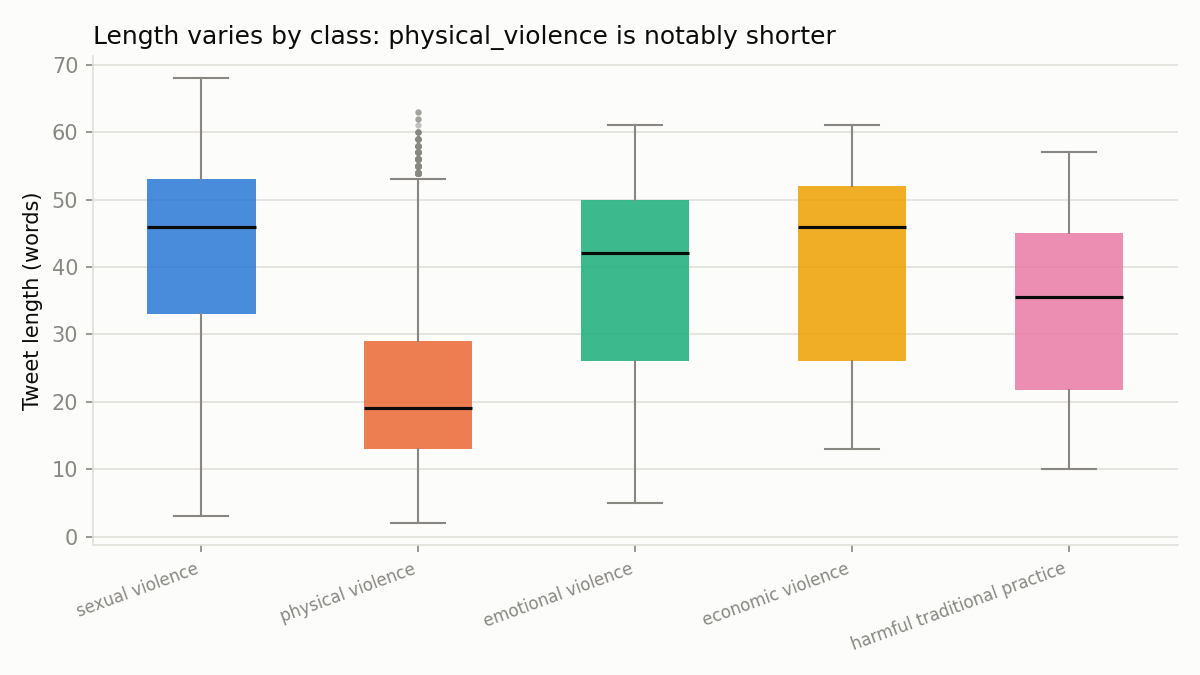

In [8]:
Image('../reports/figures/length_by_class_boxplot.png')

**What this shows:** visually, the `physical_violence` box sits noticeably lower and its interquartile range is tighter than the other four classes, confirming the table above is not driven by a few outliers. The other four classes have broadly overlapping length ranges with each other, so length alone would not separate them from one another, only from `physical_violence`.

## Vocabulary and rare words

This section looks at the words themselves: how large the vocabulary is, and how much of it is rare.

In [9]:
import re
from collections import Counter

word_counts = Counter()
for text in df['tweet_clean']:
    word_counts.update(re.findall(r"[a-z']+", text))

vocab_size = len(word_counts)
hapax = sum(1 for w, c in word_counts.items() if c == 1)
print(f'vocabulary size: {vocab_size}')
print(f'hapax legomena (appear exactly once): {hapax} ({100*hapax/vocab_size:.1f}% of vocab)')
pd.Series(dict(word_counts.most_common(15)))

vocabulary size: 37767
hapax legomena (appear exactly once): 19142 (50.7% of vocab)


me       54888
he       50210
i        47659
to       38155
and      37866
the      36127
raped    34241
a        34144
was      25701
my       25098
that     19395
of       17034
in       16361
you      15026
it       14708
dtype: int64

**What this shows:** the corpus contains 37,767 unique tokens, and 50.7% of them (19,142 words) appear exactly once in the entire dataset. That is a very long tail of rare words for a corpus this size. The 15 most frequent words are almost entirely common function words (`me`, `he`, `i`, `to`, `and`, `the`), with one striking exception: `raped` is the 7th most frequent word overall, at 34,241 occurrences, consistent with `sexual_violence` dominating the dataset. This has two consequences worth carrying into modelling decisions: first, a large rare-word tail raises the question of subword tokenization for the neural models rather than pure word-level tokenization, since the rarest classes have the fewest examples to learn whole-word representations from (the BiLSTM and TextCNN later used whole-word tokens with an out-of-vocabulary token, and only DistilBERT uses subwords); second, a model could look artificially strong on the majority class purely by keying on a small set of high-frequency keywords, which is exactly the failure mode the challenge brief itself warns against ("classify a tweet ... without using keywords").

## Data quality: duplicates and encoding noise

Finally, a check for the kind of noise that typically affects social-media text: broken encoding, near-duplicate rows, and inconsistent labels on those duplicates.

In [10]:
replacement_char_rows = df['tweet_clean'].str.contains('\ufffd', na=False).sum()
emoji_rows = df['tweet_clean'].apply(lambda t: any(ord(c) > 0x1F000 for c in t)).sum()
dup_mask = df.duplicated(subset='tweet_clean', keep=False)
dup_groups = df[dup_mask].groupby('tweet_clean')['label'].nunique()

print('rows with garbled encoding character:', replacement_char_rows)
print('rows containing emoji:', emoji_rows)
print('duplicate-text groups:', len(dup_groups))
print('duplicate-text groups with conflicting labels:', (dup_groups > 1).sum())

rows with garbled encoding character: 3
rows containing emoji: 4239
duplicate-text groups: 345
duplicate-text groups with conflicting labels: 2


**What this shows:** encoding noise is minor, with only 3 rows showing a garbled replacement character. There are effectively no hashtags, mentions, or URLs in this dataset (checked separately), so this is not noisy raw-Twitter data in the usual sense; it already looks pre-cleaned by the organizers before release. About 10.7% of rows (4,239) contain emoji, which are deliberately kept rather than stripped, since they may carry emotional signal relevant to classification. Once case and whitespace differences are normalized away, 345 groups of tweets turn out to be identical to at least one other row, and only 2 of those 345 groups carry conflicting labels across their duplicates. That is a minor data quality issue worth one sentence in the error analysis section, but not significant enough to justify deduplicating the training set.

## Cross-split duplicates

The shared split was stratified by label only, so it never looked at the text itself. Tweets that are identical after cleaning can therefore land in different splits, which lets a model score them by memorizing the training copy. This section measures how often that happens. The same check, defined once in `src/leakage.py`, is used for every model in the project.

In [11]:
import sys
sys.path.insert(0, '..')
from src.leakage import leaking_ids

split_map = pd.read_csv('../splits/train_val_test_split.csv')
merged = df.merge(split_map, on='Tweet_ID')
train_texts = set(merged.loc[merged['split'] == 'train', 'tweet_clean'])
val_texts = set(merged.loc[merged['split'] == 'val', 'tweet_clean'])
test_texts = set(merged.loc[merged['split'] == 'test', 'tweet_clean'])

print('unique cleaned texts shared between splits')
print('  train and val :', len(train_texts & val_texts))
print('  train and test:', len(train_texts & test_texts))
print('  val and test  :', len(val_texts & test_texts))
print()

labels_in_train = merged[merged['split'] == 'train'].groupby('tweet_clean')['label'].agg(set)
for name in ['val', 'test']:
    leak = merged[merged['Tweet_ID'].isin(leaking_ids(merged, name))]
    total = int((merged['split'] == name).sum())
    agree = sum(row.label in labels_in_train[row.tweet_clean] for row in leak.itertuples())
    print(f'{name}: {len(leak)} of {total} rows ({100 * len(leak) / total:.1f}%) have a copy in train')
    print('  by class:', leak['label'].value_counts().to_dict())
    print(f'  label matches the train copy in {agree} of {len(leak)} rows')

print()
print('test rows with a copy in val:', int(merged[merged['split'] == 'test']['tweet_clean'].isin(val_texts).sum()))
raw_train = set(merged.loc[merged['split'] == 'train', 'tweet'])
print('rows in val or test whose raw text (before cleaning) also appears in train:',
      int(merged[merged['split'] != 'train']['tweet'].isin(raw_train).sum()))

unique cleaned texts shared between splits
  train and val : 113
  train and test: 104
  val and test  : 29



val: 130 of 5947 rows (2.2%) have a copy in train
  by class: {'physical_violence': 106, 'sexual_violence': 21, 'emotional_violence': 1, 'economic_violence': 1, 'harmful_traditional_practice': 1}
  label matches the train copy in 129 of 130 rows


test: 117 of 5948 rows (2.0%) have a copy in train
  by class: {'physical_violence': 91, 'sexual_violence': 22, 'emotional_violence': 3, 'economic_violence': 1}
  label matches the train copy in 117 of 117 rows



test rows with a copy in val: 34


rows in val or test whose raw text (before cleaning) also appears in train: 6


**What this shows:** 113 distinct cleaned texts appear in both train and validation, 104 in both train and test, and 29 in both validation and test. In rows, 130 of the 5,947 validation tweets (2.2%) and 117 of the 5,948 test tweets (2.0%) have a copy in train, and 34 test tweets have a copy in validation. Only 6 rows across validation and test match a training tweet before cleaning, so these are mostly near-duplicates that differ in capitalization, spacing, or quote characters and become identical once cleaned. The label agrees with the training copy in 129 of the 130 validation rows and in all 117 test rows, so memorizing the training copy would almost always give the right answer. The single exception is a duplicate pair with conflicting labels, the kind already noted in the previous section.

The affected rows sit almost entirely in the two large classes. `physical_violence` accounts for 106 of the 130 validation rows and 91 of the 117 test rows, while the three rarest classes together account for only 3 validation rows and 4 test rows. Because of that, any inflation of macro F1 should be small, and the baseline notebook measures it directly on a model's predictions. The split itself is kept as it is, since rebuilding it would change the data every model has already been trained on, for an effect that turns out to be small. Instead, every model is also scored on the leak-free subset: the 5,817 validation rows and 5,831 test rows that have no copy in train.

## Summary: what this means for modelling

This section distills every finding above into direct implications for preprocessing and model selection, for use in the Data Understanding and Related Work sections of the report.

**Severe long-tail imbalance.** Two classes fall under 1% of the data (`economic_violence` at 0.55%, `harmful_traditional_practice` at 0.47%). Accuracy alone is misleading here, even though it is the actual Zindi leaderboard metric. Macro-F1 and per-class recall are needed to see whether a model has learned anything about the rare classes at all, and the fixed stratified train/validation/test split exists specifically to keep this imbalance consistent across every model's evaluation.

**Long-form text, not short-text.** Median length is 43 words with an apparent truncation ceiling near 68 words. This is closer to short-document classification than tweet-style short-text classification, which should guide which prior literature is cited as relevant and how the max sequence length is chosen for the neural models.

**Length varies systematically by class.** `physical_violence` is much shorter than the other four classes. This is a confound worth checking for specifically during error analysis, since a model could be partly responding to length rather than content.

**Large, sparse, long-tailed vocabulary.** Half of the 37,767-word vocabulary appears only once. This raises subword tokenization as an option for the neural models, given how few labeled examples exist for the rarest classes to begin with, although the BiLSTM and TextCNN ended up using whole-word tokens with an out-of-vocabulary token (see the Part 1 report).

**Minimal raw-Twitter noise.** There are no hashtags or mentions and negligible encoding issues. Preprocessing effort should go into normalization and tokenization choices rather than into stripping social-media artifacts that mostly are not present in this data.

**Cross-split duplicates.** About 2% of validation and test tweets (130 and 117 rows) have a near-identical copy in the training split, mostly in `physical_violence`. That is small enough to keep the split as it is, but every model is also scored on the leak-free subset so any inflation from memorization stays visible.